<a href="https://colab.research.google.com/github/Sarvesh-joshi273/sarvesh/blob/main/sarvesh17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
ss=files.upload()

Saving heart - heart.csv to heart - heart.csv


In [5]:
data=pd.read_csv("heart.csv")

In [6]:
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [8]:
data.shape


(918, 12)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [10]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [11]:
data.duplicated().sum()
data = data.drop_duplicates()
data.shape

(918, 12)

In [12]:
chol_zero = (data['Cholesterol'] == 0).sum()
chol_zero
bp_zero = (data['RestingBP'] == 0).sum()
bp_zero

np.int64(1)

In [14]:
print("Before cleaning:\n", data[['Cholesterol','RestingBP']])

data.loc[data['Cholesterol']==0,'Cholesterol'] = data.loc[data['Cholesterol']!=0,'Cholesterol'].mean()
data.loc[data['RestingBP']==0,'RestingBP'] = data.loc[data['RestingBP']!=0,'RestingBP'].mean()

data['Cholesterol'] = data['Cholesterol'].round(2)
data['RestingBP'] = data['RestingBP'].round(2)

print("\nAfter cleaning:\n", data[['Cholesterol','RestingBP']])


Before cleaning:
      Cholesterol  RestingBP
0          289.0      140.0
1          180.0      160.0
2          283.0      130.0
3          214.0      138.0
4          195.0      150.0
..           ...        ...
913        264.0      110.0
914        193.0      144.0
915        131.0      130.0
916        236.0      130.0
917        175.0      138.0

[918 rows x 2 columns]

After cleaning:
      Cholesterol  RestingBP
0          289.0      140.0
1          180.0      160.0
2          283.0      130.0
3          214.0      138.0
4          195.0      150.0
..           ...        ...
913        264.0      110.0
914        193.0      144.0
915        131.0      130.0
916        236.0      130.0
917        175.0      138.0

[918 rows x 2 columns]


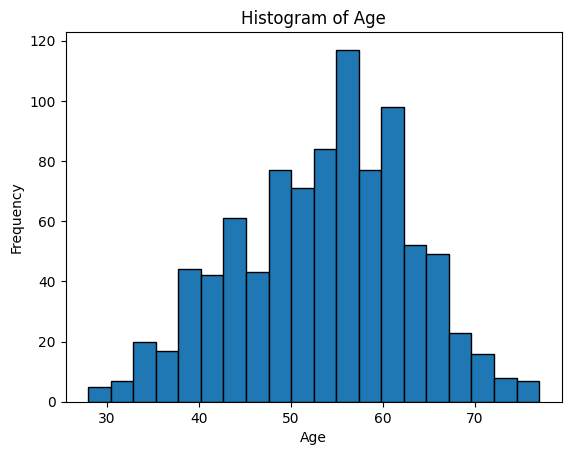

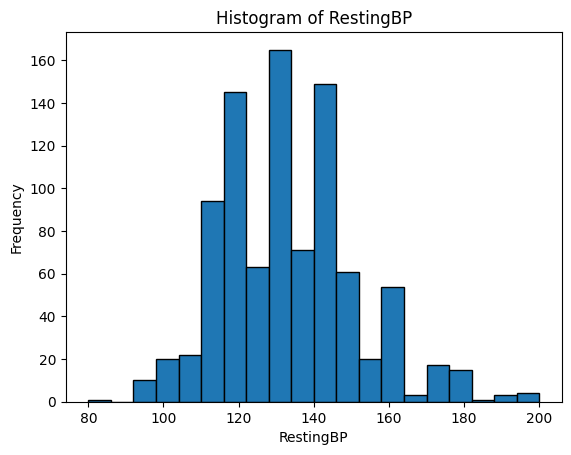

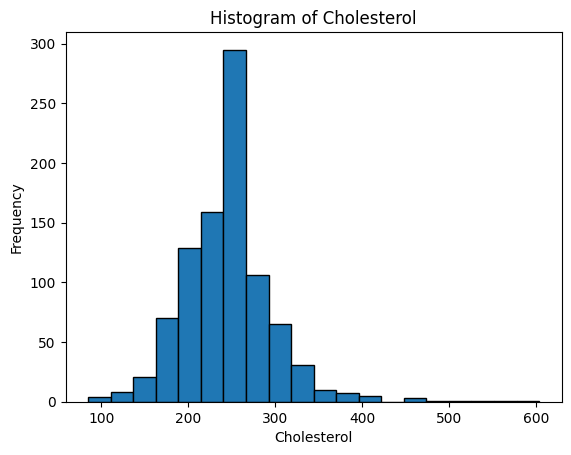

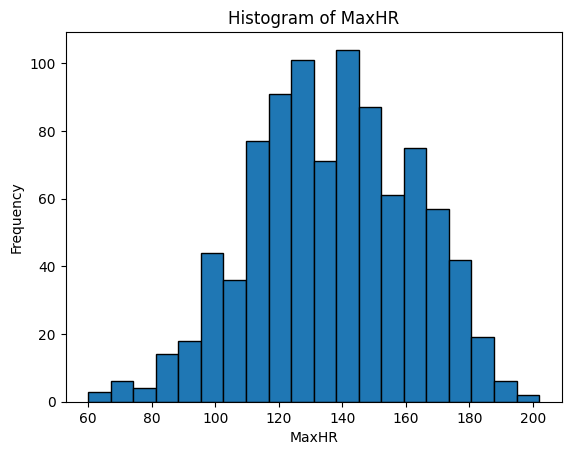

In [15]:
def plot_histograms(df, columns):
    for col in columns:
        plt.hist(df[col], bins=20, edgecolor='black')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

plot_histograms(data, ['Age', 'RestingBP', 'Cholesterol', 'MaxHR'])


In [17]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
num_cols



Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [18]:
cat_cols = data.select_dtypes(include=['object']).columns
cat_cols


Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [19]:
df_encoded = pd.get_dummies(data, drop_first=False)

print("Shape of encoded dataframe:", df_encoded.shape)
print(df_encoded.head(5))


Shape of encoded dataframe: (918, 21)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_

In [20]:
df_encoded = pd.get_dummies(data)

df_encoded.shape

df_encoded.columns.tolist()


['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']